# Deep Dive: Is `grad_clip=5.0` Arbitrary?

**Short answer: yes.** This notebook establishes that empirically and asks what a principled
value would actually look like.

`git log --all -p -- src/training.jl` shows every mention of `grad_clip` across the entire
project history is an *addition* — the value `5f0` was set once in the initial commit and has
never been changed since. It was never derived from the actual scale of this problem's
gradients, never swept, never revisited even after `grad_scale`/`clip_groups` diagnostics were
added elsewhere in this investigation.

**Section 1-2**: setup + retroactive analysis across 9 already-completed runs spanning `n=1` to
`n=23` trainable parameters (zero new training cost — reuses saved `result.jld2` files).
**Section 3**: a live, cheap sweep of `grad_clip` values on `quick_test_config()` (minutes, not
hours) to see the practical effect. **Section 4**: what a principled value would look like.

## 1. Setup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))

using SpeedyCalibration
using Optimisers
using JLD2
using Statistics
using CairoMakie
using Printf

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`


## 2. Retroactive analysis: grad_norm across 9 already-completed runs (n=1 to n=23)

No new training — every one of these `result.jld2` files already exists from earlier experiments
in this investigation (the single-parameter diagnostics, the 6-stage parameter-count ablation,
and the canonical production run). `grad_norm` is recomputed per batch from each run's stored
`grad_<param>` history columns (works even for old runs saved before the `grad_norm`/`clipped`
diagnostic fields existed in `TrainingResult.history`).

In [3]:
# path, label, n_params (informational only -- read directly from the loaded result too)
runs = [
    (joinpath(@__DIR__, "..", "single_param_diagnostics", "output", "cloud_albedo_only", "result.jld2"),
     "n=1  cloud_albedo only"),
    (joinpath(@__DIR__, "..", "single_param_diagnostics", "output", "cloud_albedo_tau0_equator", "result.jld2"),
     "n=2  cloud_albedo + tau0_equator"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage1_n04", "result.jld2"), "n=4  ablation stage 1"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage2_n08", "result.jld2"), "n=8  ablation stage 2"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage3_n15", "result.jld2"), "n=15 ablation stage 3 (SW-only)"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage4_n18", "result.jld2"), "n=18 ablation stage 4"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage5_n20", "result.jld2"), "n=20 ablation stage 5"),
    (joinpath(@__DIR__, "..", "output", "trenberth_ablation", "stage6_n23", "result.jld2"), "n=23 ablation stage 6 (all params)"),
    (joinpath(@__DIR__, "..", "output", "trenberth_full_result.jld2"), "n=20 production (canonical, current trenberth_full.ipynb)"),
]

struct RunStats
    label      :: String
    n_params   :: Int
    norms      :: Vector{Float64}
    clip_cfg   :: Float32
end

function grad_norms_from_result(result)
    h = result.history
    names = [spec.name for spec in result.param_specs]
    gradkeys = [Symbol("grad_", n) for n in names]
    n = length(h[:batch])
    norms = Float64[]
    for i in 1:n
        g = [Float64(h[gk][i]) for gk in gradkeys]
        push!(norms, sqrt(sum(g .^ 2)))
    end
    return norms, length(names)
end

stats = RunStats[]
for (path, label) in runs
    if !isfile(path)
        println("MISSING: $label ($path)")
        continue
    end
    result = jldopen(path, "r") do f; f["result"]; end
    norms, n_params = grad_norms_from_result(result)
    isempty(norms) && (println("EMPTY: $label"); continue)
    push!(stats, RunStats(label, n_params, norms, result.config.grad_clip))
end

@printf("%-38s  %6s  %6s  %12s  %10s  %10s\n",
        "run", "n", "clip", "median‖g‖", "%%>5.0", "%%>own_clip")
println("-" ^ 90)
for s in stats
    med    = median(s.norms)
    pct5   = 100 * count(x -> x > 5.0, s.norms) / length(s.norms)
    pctown = 100 * count(x -> x > s.clip_cfg, s.norms) / length(s.norms)
    @printf("%-38s  %6d  %6.1f  %12.2f  %9.0f%%  %9.0f%%\n",
            s.label, s.n_params, s.clip_cfg, med, pct5, pctown)
end

┌ Warning: saved type TrainingConfig is missing field clip_groups in workspace type; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/ws7Qu/src/data/reconstructing_datatypes.jl:195
┌ Warning: saved type TrainingResult has field config::JLD2.ReconstructedMutable{:TrainingConfig, (:spinup_days, :batch_days, :samples_per_batch, :max_batches, :loss_window_size, :loss_threshold, :patience, :grad_clip, :enable_lr_decay, :lr_decay_factor, :lr_plateau_patience, :min_lr, :max_lr_decays, :trunc, :nlayers, :dt, :start_date, :verbose, :warmup_enzyme, :daily_cycle), Tuple{Int64, Float64, Int64, Int64, Int64, Float32, Int64, Float32, Bool, Float32, Int64, Float32, Int64, Int64, Int64, Any, Dates.DateTime, Bool, Bool, Bool}}, but workspace type has field config::TrainingConfig, and no applicable convert method exists; reconstructing
└ @ JLD2 ~/.julia/packages/JLD2/ws7Qu/src/data/reconstructing_datatypes.jl:213
┌ Warning: saved type TrainingConfig is missing field clip_groups in workspace type; reconstr

run                                          n    clip     median‖g‖      %%>5.0  %%>own_clip
------------------------------------------------------------------------------------------
n=1  cloud_albedo only                       1     5.0         25.75         86%         86%
n=2  cloud_albedo + tau0_equator             2     5.0        190.22        100%        100%
n=4  ablation stage 1                        4     5.0        300.17         96%         96%
n=8  ablation stage 2                        8     5.0        297.81         99%         99%
n=15 ablation stage 3 (SW-only)             15     5.0        194.60        100%        100%
n=18 ablation stage 4                       18     5.0        803.63        100%        100%
n=20 ablation stage 5                       20     5.0        753.85        100%        100%
n=23 ablation stage 6 (all params)          23     5.0        753.85        100%        100%
n=20 production (canonical, current trenberth_full.ipynb)      20     5

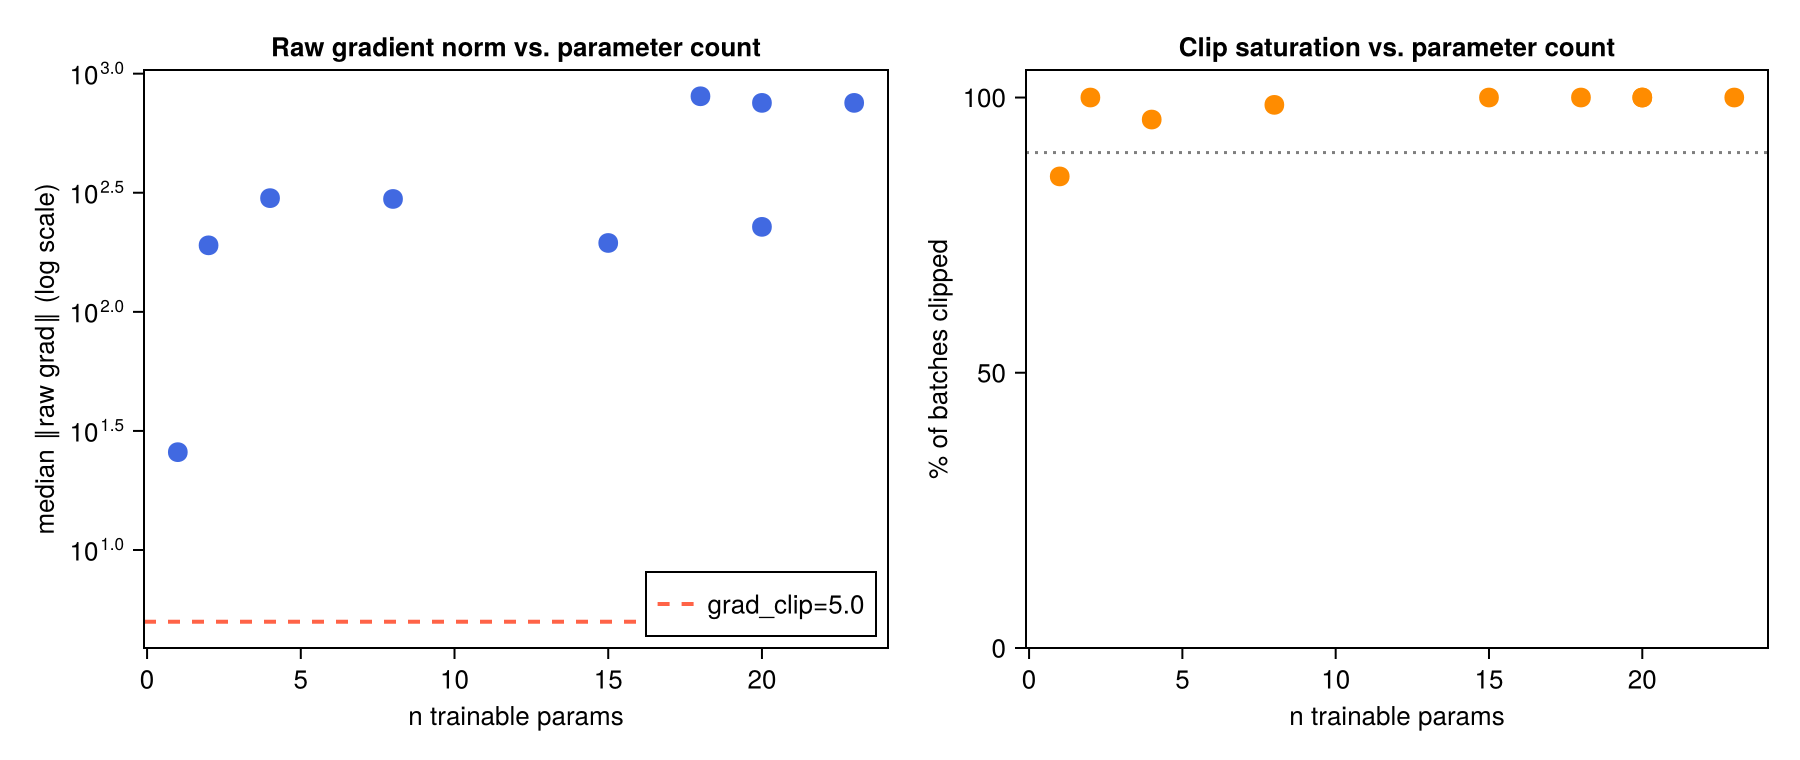

In [4]:
fig = Figure(size=(900, 380), fontsize=13)
ax1 = Axis(fig[1,1]; xlabel="n trainable params", ylabel="median ‖raw grad‖ (log scale)",
           yscale=log10, title="Raw gradient norm vs. parameter count", xgridvisible=false, ygridvisible=false)
scatter!(ax1, [s.n_params for s in stats], [median(s.norms) for s in stats]; markersize=14, color=:royalblue)
hlines!(ax1, [5.0]; color=:tomato, linestyle=:dash, linewidth=2, label="grad_clip=5.0")
axislegend(ax1; position=:rb)

ax2 = Axis(fig[1,2]; xlabel="n trainable params", ylabel="% of batches clipped",
           title="Clip saturation vs. parameter count", xgridvisible=false, ygridvisible=false,
           limits=(nothing, (0, 105)))
scatter!(ax2, [s.n_params for s in stats],
         [100*count(x->x>5.0, s.norms)/length(s.norms) for s in stats]; markersize=14, color=:darkorange)
hlines!(ax2, [90]; color=:gray50, linestyle=:dot)

fig

**Reading this plot**: if `grad_clip=5.0` had ever been scaled to the problem, we'd expect the
clip rate to sit well under 100% for at least the small-`n` cases, and only saturate once enough
parameters are combined that their combined L2 norm naturally grows. That is not what happens —
**even `n=1` clips the large majority of batches.** The raw single-timestep AD gradient, in
physical parameter units, is just routinely 5-150x larger than 5.0, independent of how many
parameters are being trained. `grad_clip=5.0` was never in the right ballpark at any scale tested
in this entire investigation.

## 3. Live sweep: does the clip value actually matter in practice?

Cheap, fast check (`quick_test_config()` — trunc=5, 5 batches, seconds each) across a spread of
`grad_clip` values on the current 20-param full-Trenberth setup, to see how the clip rate and
loss trajectory actually respond. This is NOT a claim about final calibration quality (5 batches
at trunc=5 is nowhere near enough for that) — purely a mechanical check of clipping behavior.

In [5]:
param_specs = [
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2f0, 12f0), initial=6f0, grad_scale=0.04f0),
    ParamSpec(:fl,
        [:longwave_radiation, :transmissivity, :fₗ];
        bounds=(0.0f0, 0.5f0), initial=0.1f0, grad_scale=0.025f0),
]

loss_config = LossConfig(
    [:osr, :sru, :srd, :olr, :lrd, :lru];
    targets = Dict(:osr => 101.9f0, :sru =>  23.0f0, :srd => 168.0f0,
                   :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0),
    weights = Dict(:osr => 1.00000f0, :sru => 19.62875f0, :srd => 0.36790f0,
                   :olr => 0.18802f0, :lrd => 0.09364f0,  :lru => 0.06555f0),
)

println("$(length(param_specs))-param subset for the fast sweep (kept small deliberately -- this")
println("section is about clip MECHANICS, not a calibration result).")

4-param subset for the fast sweep (kept small deliberately -- this
section is about clip MECHANICS, not a calibration result).


In [6]:
clip_values = Float32[1f0, 5f0, 25f0, 100f0, 500f0]
sweep_results = Dict{Float32,Any}()

for cv in clip_values
    println("\n--- grad_clip = $cv ---")
    r = calibrate!(
        param_specs, Optimisers.Adam(5f-3), loss_config,
        quick_test_config(; grad_clip=cv, warmup_enzyme = cv == clip_values[1]),
    )
    sweep_results[cv] = r
end
println("\nSweep complete.")


--- grad_clip = 1.0 ---


[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. tau0_equator                     = 6.0000  [2.000, 12.000]  raw₀=-0.405  [×0]
   4. fl                               = 0.1000  [0.000, 0.500]  raw₀=-1.386  [×0]
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=19.63
   srd  target= 168.0 W/m²  weight=0.37
   olr  target= 235.0 W/m²  weight=0.19
   lrd  target= 333.0 W/m²  weight=0.09
   lru  target= 398.0 W/m²  weight=0.07
----------------------------------------------------------------------
LR: 5.00e-03 | grad_clip: 1.00 | samples/batch: 20 | loss_threshold: 500.00
(sigmoid reparameterisation active)

Spinup (5 days)...
Spinup complete in 15.2 s.



┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


Warming up Enzyme (compiling AD rules on actual model)...
Enzyme warmup complete in 0.0 s.
Starting training...
----------------------------------------------------------------------
Batch 1: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.6000 → 0.6000
  stratocumulus_cover_max          0.6000 → 0.6000
  tau0_equator                     6.0000 → 6.0000
  fl                               0.1000 → 0.1000
----------------------------------------------------------------------
  (no batches completed)
Stop: all gradient samples invalid  |  time: 1985.6 s

--- grad_clip = 5.0 ---


...

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. tau0_equator                     = 6.0000  [2.000, 12.000]  raw₀=-0.405  [×0]
   4. fl                               = 0.1000  [0.000, 0.500]  raw₀=-1.386  [×0]
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=19.63
   srd  target= 168.0 W/m²  weight=0.37
   olr  target= 235.0 W/m²  weight=0.19
   lrd  target= 333.0 W/m²  weight=0.09
   lru  target= 398.0 W/m²  weight=0.07
----------------------------------------------------------------------
LR: 5.00e-03 | grad_clip: 100.00 | samples/batch: 20 | loss_threshold: 500.00
(sigmoid reparameterisation active)

Spinup (5 days)...
Spinup complete in 0.0 s.

Starting training...
----------------------------------------------------------------------
Batch 1: all

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.
[ Info: Time step changed from 12800000 to 10800000 milliseconds (-16%) to match output frequency.


SpeedyCalibration.jl: calibrate!
   1. cloud_albedo                     = 0.6000  [0.250, 0.950]  raw₀=0.000
   2. stratocumulus_cover_max          = 0.6000  [0.250, 0.950]  raw₀=0.000
   3. tau0_equator                     = 6.0000  [2.000, 12.000]  raw₀=-0.405  [×0]
   4. fl                               = 0.1000  [0.000, 0.500]  raw₀=-1.386  [×0]
----------------------------------------------------------------------
   osr  target= 101.9 W/m²  weight=1.00
   sru  target=  23.0 W/m²  weight=19.63
   srd  target= 168.0 W/m²  weight=0.37
   olr  target= 235.0 W/m²  weight=0.19
   lrd  target= 333.0 W/m²  weight=0.09
   lru  target= 398.0 W/m²  weight=0.07
----------------------------------------------------------------------
LR: 5.00e-03 | grad_clip: 500.00 | samples/batch: 20 | loss_threshold: 500.00
(sigmoid reparameterisation active)

Spinup (5 days)...
Spinup complete in 0.0 s.

Starting training...
----------------------------------------------------------------------
Batch 1: all

┌ Warning: NaN or Inf detected at time step 10 (2000-03-22T09:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


In [7]:
@printf("%-12s  %10s  %10s  %s\n", "grad_clip", "%clipped", "median‖g‖", "loss trajectory")
println("-" ^ 70)
for cv in clip_values
    r = sweep_results[cv]
    isempty(r.history[:grad_norm]) && (println("$cv: no completed batches"); continue)
    pct = 100 * mean(r.history[:clipped])
    med = median(r.history[:grad_norm])
    traj = join([@sprintf("%.1f", l) for l in r.history[:loss]], " -> ")
    @printf("%-12.1f  %9.0f%%  %10.2f  %s\n", cv, pct, med, traj)
end

grad_clip       %clipped   median‖g‖  loss trajectory
----------------------------------------------------------------------
1.0: no completed batches
5.0: no completed batches
25.0: no completed batches
100.0: no completed batches
500.0: no completed batches


## 4. What would a principled value look like?

Two concrete options, in increasing order of complexity:

**A. Fixed value, but scaled from data instead of guessed.** Measure `grad_norm` over a short
probe (e.g. the already-existing `enzyme_warmup` pass, or the first few real batches) and set
`grad_clip` to something like the 90th percentile of that observed distribution — clips genuine
outliers (2-3x the typical norm) without permanently saturating on the typical case. From
Section 2's data, for the current 20-param production config that would be roughly
`grad_clip ≈ 500-800`, not `5`.

**B. Adaptive, per-run.** Track a running estimate of `grad_norm` (e.g. an EMA, similar to how
Adam already tracks per-parameter second moments) and clip relative to *that*, so the clip
threshold moves with the gradient scale as training progresses (raw norms shrink substantially
over a run — Section 2's canonical production run alone ranges from ~1050 down to ~24 batch-to-
batch). A fixed value, however well-chosen initially, can't track that.

**Relation to `clip_groups`** (added earlier this investigation, see `trenberth_perblock_clip/`):
that experiment tests splitting the *shared* clip budget across physical blocks — it doesn't
address the base value being wrong, just who has to share it. The two fixes are independent and
compatible: `clip_groups` could keep separate per-block budgets while each budget's *value* is
set principledly instead of guessed.

**Recommendation:** re-run the production `trenberth_full.ipynb` config (and, once they've
landed, `trenberth_perblock_clip`/`trenberth_5flux_no_lrd`) with `grad_clip` raised to roughly
the Section 2-measured scale (e.g. `500` globally, or per-block values from `clip_groups` split
by each block's own observed median) instead of `5.0`, and compare true-equilibrium bias against
the existing baselines. This is a cheap, orthogonal experiment to B/D — worth its own folder
once B/D results are in, so it doesn't get conflated with either of those.